# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**A1.**
1. A model is "linear" if its parameters aka coefficients are added together rather than multipled or squared or power of anything. There should be a constant rate of change, implying a straight-line trend. 
2. For a dummy variable, the coefficient represents the difference in the expected outcome relative to the baseline category. Or in other words, it measures how much the expected outcomes changes compared to the baseline category. 
3. Linear regression cannot be used for classification because it can have prediction values that are outside of the classification range (0/1).
4. If the train accuracy is high but then the test accuracy is not. If there are huge number of predictors in comparison to observations. If we have very large coefficients.
5. Say we regress one explanatory vairable on the others. If that regression gives us a very high coefficient of determination, it would mean that the variable can almost be predicted by using the other predictors, which further means that the variable does not have much indepedent information. This is a prime example of multicollinearity, where variables are highly correlated with each other, hard to gather independent info them.
6. We can transform our predictors through log transformations, polynomial, piecewise, so on so forth. 
7. the slope coefficient represents the expected change in the dependent variable for a one unit increase in the predictor, holding all other variables constant.
8. The train/test-split splits the dataset into one training and one testing set while k-fold cross validation splits the data into k partts and train and tests the model k number of times, each time using a different fold as the testing set. We prefer the k-fold cross validation.
9. The k in k-fold is chosen by determining which k results in the best accuracy, this may take multiple tries.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

#Q1
airbnb = pd.read_csv('./data/Q1_clean.csv')
airbnb.columns = airbnb.columns.str.strip()
airbnb.head()

avg_price_rating = airbnb.groupby("Neighbourhood").agg({"Price": "mean", "Review Scores Rating": "mean"}).reset_index()

print(avg_price_rating)

   Neighbourhood       Price  Review Scores Rating
0          Bronx   75.276498             91.654378
1       Brooklyn  127.747378             92.363497
2      Manhattan  183.664286             91.801496
3         Queens   96.857233             91.549057
4  Staten Island  146.166667             90.843750


In [80]:
#Q2
dummies = pd.get_dummies(airbnb['Neighbourhood'], drop_first=True)
X = dummies
y = airbnb['Price']
model = LinearRegression()
model.fit(X, y)

print("Intercept (Bronx baseline):", model.intercept_)
print("Coefficients:")
for neighbourhood, coef in zip(dummies.columns, model.coef_):
    print(f"{neighbourhood}: {coef}")

print("\nGroup means from part 1:")
print(avg_price_rating)

Intercept (Bronx baseline): 75.2764976958471
Coefficients:
Brooklyn: 52.470880647496166
Manhattan: 108.38778862567729
Queens: 21.580735008529217
Staten Island: 70.89016897079334

Group means from part 1:
   Neighbourhood       Price  Review Scores Rating
0          Bronx   75.276498             91.654378
1       Brooklyn  127.747378             92.363497
2      Manhattan  183.664286             91.801496
3         Queens   96.857233             91.549057
4  Staten Island  146.166667             90.843750


The regression coefficients directly correspond to the differences in the conditional group means from part 1. Since we dropped the first dummy category to avoid the dummy variable trap, the intercept represents the baseline mean price for the Bronx. Each coefficient then measures the additional price premium for that neighbourhood compared to the Bronx. If we didn't drop Bronx, it would've caused the model to be overly specified and the coefficients would be relative to an implicit zero basline while the difference between the group would remain the same. Helps prevent multicollinearity

In [81]:
#Q3
X_rating = airbnb[['Review Scores Rating']]
y = airbnb['Price']
model_rating = LinearRegression()
model_rating.fit(X_rating, y)

print("Intercept:", model_rating.intercept_)
print("Slope coefficient for Review Scores Rating:", model_rating.coef_[0])


# For each additional point in the review score rating, the expected price increases by approximately $1.02, holding all other factors constant.

Intercept: 60.87839065711856
Slope coefficient for Review Scores Rating: 1.0208266022675305


In [82]:
#Q4 
dummies = pd.get_dummies(airbnb['Neighbourhood'], drop_first=True)
X_both = pd.concat([dummies, airbnb[['Review Scores Rating']]], axis=1)
y = airbnb['Price']
model_both = LinearRegression()
model_both.fit(X_both, y)

print("Intercept:", model_both.intercept_)
print("Coefficients:")
for feature, coef in zip(X_both.columns, model_both.coef_):
    print(f"{feature}: {coef}")

print(f"Slope for Review Scores Rating in part 3: {model_rating.coef_[0]}")
print(f"Slope for Review Scores Rating in this model: {model_both.coef_[-1]}")
mean_rating = airbnb['Review Scores Rating'].mean()
print(f"Adjusted neighbourhood averages (mean rating {mean_rating:}):")
for i, neighbourhood in enumerate(['Bronx'] + list(dummies.columns)):
    if neighbourhood == 'Bronx':
        pred = model_both.intercept_ + model_both.coef_[-1] * mean_rating
    else:
        idx = list(dummies.columns).index(neighbourhood)
        pred = model_both.intercept_ + model_both.coef_[idx] + model_both.coef_[-1] * mean_rating
    print(f"{neighbourhood}: {pred}")

#the neighborhood avg remained basically the same, with slight increases.
#the review scoee rating also is bascially the same, with a slight increase.

Intercept: -23.812561011676507
Coefficients:
Brooklyn: 51.7042401559104
Manhattan: 108.22873656677945
Queens: 21.6945995765166
Staten Island: 71.76655213401344
Review Scores Rating: 1.081116483459829
Slope for Review Scores Rating in part 3: 1.0208266022675305
Slope for Review Scores Rating in this model: 1.081116483459829
Adjusted neighbourhood averages (mean rating 91.99309348620955):
Bronx: 75.64268872072566
Brooklyn: 127.34692887663606
Manhattan: 183.8714252875051
Queens: 97.33728829724225
Staten Island: 147.4092408547391


In [83]:
#Q5
dummies_full = pd.get_dummies(airbnb['Neighbourhood'])
interactions = dummies_full.mul(airbnb['Review Scores Rating'], axis=0)
dummies_reduced = dummies_full.drop('Bronx', axis=1)
interactions_reduced = interactions.drop('Bronx', axis=1)
interactions_reduced.columns = [col + ' * Review Scores Rating' for col in interactions_reduced.columns]

X_interact = pd.concat([dummies_reduced, interactions_reduced], axis=1)
y = airbnb['Price']
model_interact = LinearRegression()
model_interact.fit(X_interact, y)

print("Intercept:", model_interact.intercept_)
print("Coefficients:")
for feature, coef in zip(X_interact.columns, model_interact.coef_):
    print(f"{feature}: {coef}")

print("Slopes for Review Scores Rating by neighborhood:")
print(f"Bronx (baseline): {0}")
for neighbourhood in dummies_reduced.columns:
    slope = model_interact.coef_[list(X_interact.columns).index(neighbourhood + ' * Review Scores Rating')]
    print(f"{neighbourhood}: {slope}")

slopes = [0] + [model_interact.coef_[list(X_interact.columns).index(n + ' * Review Scores Rating')] for n in dummies_reduced.columns]
print(f"Slopes range from {min(slopes)} to {max(slopes)}")

#The slopes differ noticeably across neighborhoods

Intercept: 75.2764976958795
Coefficients:
Brooklyn: -69.03110294922377
Manhattan: -11.322683825341379
Queens: -24.378411486879063
Staten Island: 2910.432927346977
Brooklyn * Review Scores Rating: 1.315476215108491
Manhattan * Review Scores Rating: 1.30401439392736
Queens * Review Scores Rating: 0.5020166039975847
Staten Island * Review Scores Rating: -31.25743662471173
Slopes for Review Scores Rating by neighborhood:
Bronx (baseline): 0
Brooklyn: 1.315476215108491
Manhattan: 1.30401439392736
Queens: 0.5020166039975847
Staten Island: -31.25743662471173
Slopes range from -31.25743662471173 to 1.315476215108491


In [84]:
#Q6
from sklearn.model_selection import cross_val_score

X4 = pd.concat([dummies, airbnb[['Review Scores Rating']]], axis=1)
model4 = LinearRegression()
scores4 = cross_val_score(model4, X4, y, cv=5, scoring='r2')
print("Model 4 CV R^2 scores:", scores4)
print("Mean R^2:", np.mean(scores4))
X5 = X_interact 
model5 = LinearRegression()
scores5 = cross_val_score(model5, X5, y, cv=5, scoring='r2')
print("Model 5 CV R^2 scores:", scores5)
print("Mean R^2:", np.mean(scores5))

# Compare
print(f"Model 4 mean R^2: {np.mean(scores4)}")
print(f"Model 5 mean R^2: {np.mean(scores5)}")


#Model 4 performs better on cross validation

Model 4 CV R^2 scores: [0.02620316 0.04858702 0.07006812 0.07769698 0.03123035]
Mean R^2: 0.05075712643727577
Model 5 CV R^2 scores: [0.0198296  0.0533911  0.06995801 0.02779111 0.01199711]
Mean R^2: 0.036593385617727556
Model 4 mean R^2: 0.05075712643727577
Model 5 mean R^2: 0.036593385617727556


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:
  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

Summary of Price variable:
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


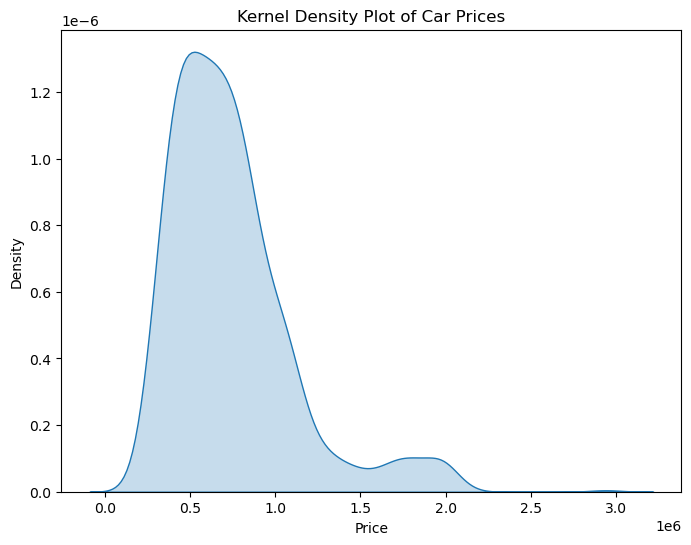

Prices summarized by Body_Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

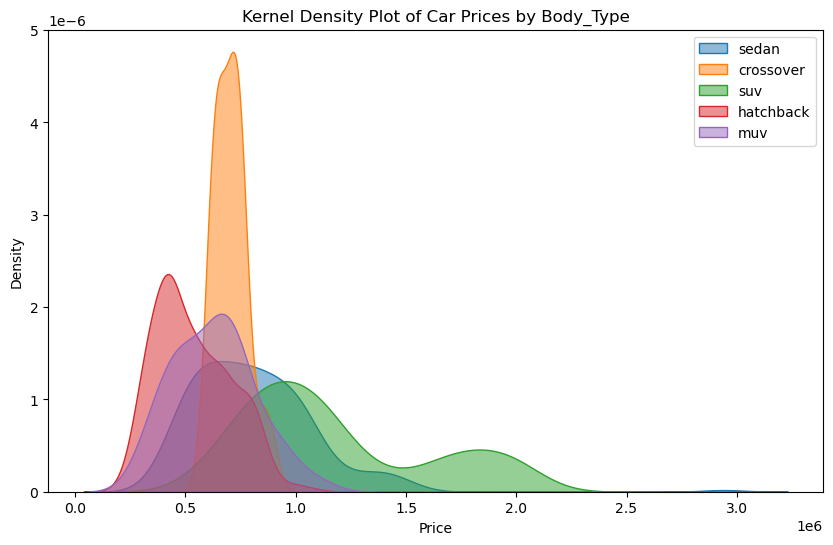

Most expensive car type (highest mean price): suv
Car type with the most variance (highest std): suv


In [85]:
#Q1
cars = pd.read_csv('./data/cars_hw.csv')

print("Summary of Price variable:")
print(cars['Price'].describe())
plt.figure(figsize=(8, 6))
sns.kdeplot(cars['Price'], fill=True)
plt.title('Kernel Density Plot of Car Prices')
plt.show()

print("Prices summarized by Body_Type:")
price_by_body = cars.groupby('Body_Type')['Price'].describe()
print(price_by_body)

plt.figure(figsize=(10, 6))
for body_type in cars['Body_Type'].unique():
    subset = cars[cars['Body_Type'] == body_type]
    sns.kdeplot(subset['Price'], label=body_type, fill=True, alpha=0.5)
plt.title('Kernel Density Plot of Car Prices by Body_Type')
plt.legend()
plt.show()
most_expensive = price_by_body['mean'].idxmax()
print(f"Most expensive car type (highest mean price): {most_expensive}")
most_variance = price_by_body['std'].idxmax()
print(f"Car type with the most variance (highest std): {most_variance}")

In [86]:
#Q2
X_seat = cars[['Seating_Capacity']]
y_price = cars['Price']
model_seat = LinearRegression()
model_seat.fit(X_seat, y_price)

print("Regression of Price on Seating_Capacity:")
print(f"Intercept: {model_seat.intercept_:.2f}")
print(f"Slope coefficient: {model_seat.coef_[0]:.2f}")

#For each additional seat, the expected price increases by approx slop coefficient, holding other factors constant.

dummies_seat = pd.get_dummies(cars['Seating_Capacity'], prefix='Seats', drop_first=True)
X_seat_cat = dummies_seat
model_seat_cat = LinearRegression()
model_seat_cat.fit(X_seat_cat, y_price)
print(f"Intercept: {model_seat_cat.intercept_}")
print("Coefficients:")
for seat, coef in zip(dummies_seat.columns, model_seat_cat.coef_):
    print(f"{seat}: {coef}")
seat_values = sorted(cars['Seating_Capacity'].unique())
print(f"Seating capacities: {seat_values}")
print("Coefficients relative to baseline:")
baseline = 4
for seat in seat_values:
    if seat == baseline:
        print(f"{seat} seats: 0 (baseline)")
    else:
        coef = model_seat_cat.coef_[list(dummies_seat.columns).index(f'Seats_{seat}')]
        print(f"{seat} seats: {coef}")
continuous_slope = model_seat.coef_[0]
print(f"Continuous slope: {continuous_slope} per seat")

#not the differences in prices are not rougly linear in the number of seats.

Regression of Price on Seating_Capacity:
Intercept: 439032.01
Slope coefficient: 59268.00
Intercept: 188000.00000001164
Coefficients:
Seats_5: 546483.87096773
Seats_6: 1455999.9999999998
Seats_7: 735948.7179487121
Seats_8: 271799.9999999942
Seating capacities: [4, 5, 6, 7, 8]
Coefficients relative to baseline:
4 seats: 0 (baseline)
5 seats: 546483.87096773
6 seats: 1455999.9999999998
7 seats: 735948.7179487121
8 seats: 271799.9999999942
Continuous slope: 59267.99803672191 per seat


Optimal degree: 3
Coefficients for degree 3: [     0.         226513.34678976 -31397.0046271    1047.19174511]
Intercept: 499883.977731884


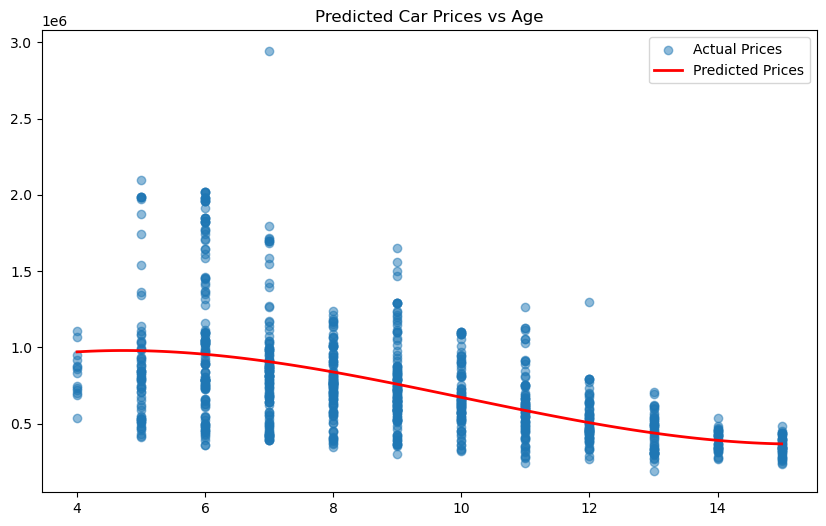

In [87]:
#Q3 and 4
cars['Age'] = 2026 - cars['Make_Year']

degrees = range(1, 11) 
cv_scores = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(cars[['Age']])
    model = LinearRegression()
    scores = cross_val_score(model, X_poly, cars['Price'], cv=10, scoring='r2')
    cv_scores.append(np.mean(scores))
optimal_degree = degrees[np.argmax(cv_scores)]
print(f"Optimal degree: {optimal_degree}")
poly_opt = PolynomialFeatures(degree=optimal_degree)
X_poly_opt = poly_opt.fit_transform(cars[['Age']])
model_opt = LinearRegression()
model_opt.fit(X_poly_opt, cars['Price'])
print(f"Coefficients for degree {optimal_degree}: {model_opt.coef_}")
print(f"Intercept: {model_opt.intercept_}")
age_range = np.linspace(cars['Age'].min(), cars['Age'].max(), 100).reshape(-1, 1)
poly_opt = PolynomialFeatures(degree=3)
X_pred = poly_opt.fit_transform(age_range)
y_pred = model_opt.predict(X_pred)

plt.figure(figsize=(10, 6))
plt.scatter(cars['Age'], cars['Price'], alpha=0.5, label='Actual Prices')
plt.plot(age_range, y_pred, color='red', linewidth=2, label='Predicted Prices')
plt.title('Predicted Car Prices vs Age')
plt.legend()
plt.show()

# The cubic model captures the non-linear relationship, with prices decreasing as age increases, but the fit is moderate menaing that other factors influence price.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [88]:
#Q1
heart = pd.read_csv('./data/heart_hw.csv')
control_survival = heart[heart['transplant'] == 'control']['y'].mean()
print(f"Proportion surviving in control group: {control_survival}")
treatment_survival = heart[heart['transplant'] == 'treatment']['y'].mean()
print(f"Proportion surviving in treatment group: {treatment_survival}")
ATE = treatment_survival - control_survival
print(f"ATE on three-year survival: {ATE}")

Proportion surviving in control group: 0.11764705882352941
Proportion surviving in treatment group: 0.34782608695652173
ATE on three-year survival: 0.23017902813299232


In [89]:
#Q2
heart['transplant_dummy'] = (heart['transplant'] == 'treatment').astype(int)
X_transplant = heart[['transplant_dummy']]
y_heart = heart['y']
model_transplant = LinearRegression()
model_transplant.fit(X_transplant, y_heart)
print("Intercept:", model_transplant.intercept_)
print("Transplant coefficient:", model_transplant.coef_[0])

#The intercept matches the control group survival proportion, and the coefficient matches the ATE from part 1.

Intercept: 0.11764705882352966
Transplant coefficient: 0.23017902813299193


Intercept: 0.701956972174095
Transplant coefficient: 0.2647016865036745
Age coefficient: -0.013607217160218643
Prev transplant coefficient (without age): 0.23017902813299193


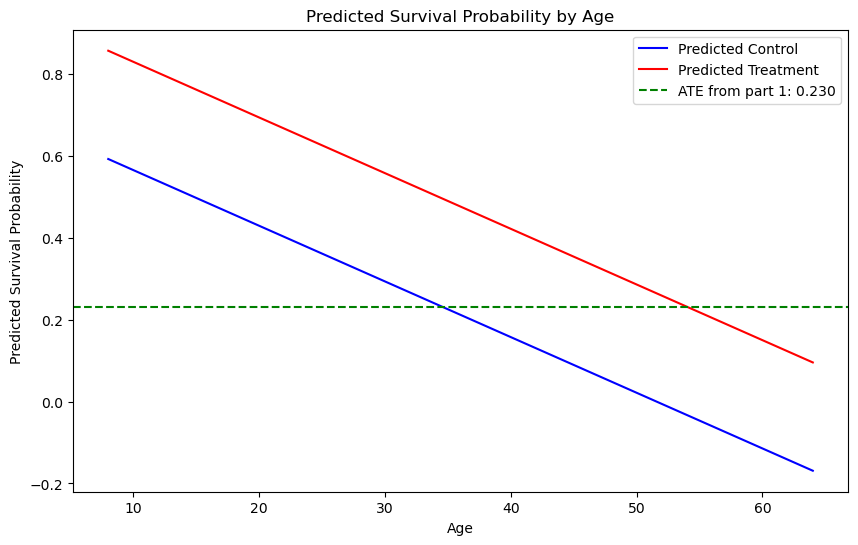

In [90]:
#Q3
X_age_transplant = heart[['transplant_dummy', 'age']]
model_age_transplant = LinearRegression()
model_age_transplant.fit(X_age_transplant, y_heart)
print("Intercept:", model_age_transplant.intercept_)
print("Transplant coefficient:", model_age_transplant.coef_[0])
print("Age coefficient:", model_age_transplant.coef_[1])

print(f"Prev transplant coefficient (without age): {model_transplant.coef_[0]}")
#The transplant coefficient decreases slightly when controlling for age, meaning some confounding by age. The intercept predicted survival for control group at age 0. The age slope is the change in survival probability per additional year of age. Transplant coefficient is adjusted ATE, holding age constant

ages = np.linspace(heart['age'].min(), heart['age'].max(), 100)
pred_control = model_age_transplant.intercept_ + model_age_transplant.coef_[1] * ages
pred_treatment = pred_control + model_age_transplant.coef_[0]

plt.figure(figsize=(10, 6))
plt.plot(ages, pred_control, label='Predicted Control', color='blue')
plt.plot(ages, pred_treatment, label='Predicted Treatment', color='red')
plt.axhline(y=ATE, linestyle='--', color='green', label=f'ATE from part 1: {ATE:.3f}')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.title('Predicted Survival Probability by Age')
plt.legend()
plt.show()

#The ATE overestimates the transplant effect for younger ages and underestimates for older ages. Specifically, for ages where the treatment line is above the ATE line, the model predicts a larger effect than the raw ATE, below is smaller. 

Intercept: 0.35486517529945927
Transplant coefficient: 0.9077513885685884
Age coefficient: -0.005524257506973686
Transplant*Age coefficient: -0.014590638256855288


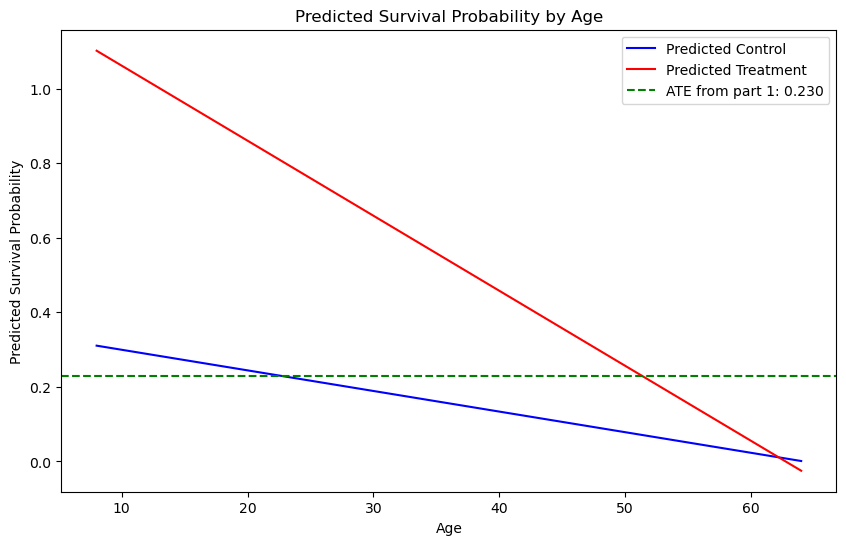

In [91]:
#Q4
heart['transplant_age'] = heart['transplant_dummy'] * heart['age']
X_interact = heart[['transplant_dummy', 'age', 'transplant_age']]
model_interact = LinearRegression()
model_interact.fit(X_interact, y_heart)
print("Intercept:", model_interact.intercept_)
print("Transplant coefficient:", model_interact.coef_[0])
print("Age coefficient:", model_interact.coef_[1])
print("Transplant*Age coefficient:", model_interact.coef_[2])
pred_control_interact = model_interact.intercept_ + model_interact.coef_[1] * ages
pred_treatment_interact = pred_control_interact + model_interact.coef_[0] + model_interact.coef_[2] * ages
plt.figure(figsize=(10, 6))
plt.plot(ages, pred_control_interact, label='Predicted Control', color='blue')
plt.plot(ages, pred_treatment_interact, label='Predicted Treatment', color='red')
plt.axhline(y=ATE, linestyle='--', color='green', label=f'ATE from part 1: {ATE:.3f}')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.title('Predicted Survival Probability by Age')
plt.legend()
plt.show()

#Change in predictions: Now the transplant effect varies with age
#The effect of transplant increases with age, meaning older patients benefit more from transplants.
#Compared to part 3, the lines are no longer parallel aka the gap widens with age.

In [92]:
#Q5
from sklearn.model_selection import cross_val_score

scores2 = cross_val_score(model_transplant, X_transplant, y_heart, cv=10, scoring='r2')
print("Model 2 (transplant only) CV R^2:", scores2)
print("Mean R^2:", np.mean(scores2))
scores3 = cross_val_score(model_age_transplant, X_age_transplant, y_heart, cv=10, scoring='r2')
print("Model 3 (transplant + age) CV R^2:", scores3)
print("Mean R^2:", np.mean(scores3))
scores4 = cross_val_score(model_interact, X_interact, y_heart, cv=10, scoring='r2')
print("Model 4 (with interaction) CV R^2:", scores4)
print("Mean R^2:", np.mean(scores4))
print(f"Model 2 mean R^2: {np.mean(scores2)}")
print(f"Model 3 mean R^2: {np.mean(scores3)}")
print(f"Model 4 mean R^2: {np.mean(scores4)}")


Model 2 (transplant only) CV R^2: [ 0.         -0.39967725 -0.01281499  0.          0.          0.08866264
 -0.57164479 -1.86392476 -0.36239586 -0.92211728]
Mean R^2: -0.40439122900114255
Model 3 (transplant + age) CV R^2: [ 0.         -0.80481243 -0.07206204  0.          0.          0.44092856
 -1.76872954 -2.0376119  -0.082461   -0.62357875]
Mean R^2: -0.49483270983780747
Model 4 (with interaction) CV R^2: [ 0.         -0.84878581  0.08453514  0.          0.          0.56816435
 -1.62764372 -2.48778396  0.02074505 -0.6191084 ]
Mean R^2: -0.4909877360366102
Model 2 mean R^2: -0.40439122900114255
Model 3 mean R^2: -0.49483270983780747
Model 4 mean R^2: -0.4909877360366102


**Q6**
Some constructions concerns are that linear regression would not be good for classification, should use logistic reg instead. The small dataset likely leads to overfitting, and there are missing confounding factirs like ejection fraction that ends up biasing the estimates. Additionally, selection bias in who gets transplants can distort effects.

Some deplyment concerns include ethical issues where prioritizing based on predicted survival could discriminate against older patients or those with lower predicted benefits, raising equity concerns. Additionally, if training data underrepresents certain groups, the model would only enhance disparities. Age-dependent effects could unfairly favor younger patients, and  external validation on new data is needed because the model may not generalize.